In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import math
from scipy.stats import skewnorm
from scipy import special
from scipy.special import gamma,psi
from scipy.spatial.distance import cdist
import os
import random
from sklearn.metrics import DistanceMetric
dist = DistanceMetric.get_metric('euclidean')
import copy
import seaborn as sns
from scipy.stats import chi2, multivariate_normal
import time
import itertools
from scipy.stats import linregress
from sklearn.neighbors import NearestNeighbors
from datetime import datetime, timedelta
from scipy.special import gammaln

In [2]:
primary_colors = [
    '#F44336',
    '#E91E63',  
    '#9C27B0',  
    '#673AB7',
    '#3F51B5', 
    '#2196F3',
    '#03A9F4',
    '#00BCD4',
    '#009688',
    '#4CAF50',
    '#8BC34A',
    '#CDDC39',
    '#FFEB3B',
    '#FFC107',
    '#FF9800',
    '#FF5722',
    '#795548',
    '#9E9E9E',
    '#607D8B'
]

In [5]:
def renyi_Leonenko(neigh_num,alphas,data):

    m=data.shape[1]
    V=pow(math.pi,m/2)/math.gamma(m/2+1)  

    max_k = max(neigh_num)+1

    knn = NearestNeighbors(n_neighbors=max_k, algorithm='brute', metric='euclidean')
  

    knn.fit(data)

    distances, indices = knn.kneighbors(data)

    H=list()

    for q in alphas:
        kn=list()
        for k in neigh_num:
            C=pow(np.exp( gammaln(k) - gammaln(k + 1 - q) ),1/(1-q))
            knn=distances[:, k]       
            knn=knn[np.where(knn>0)]
            norm=len(knn)
            I=np.sum(pow(pow(knn,m)*V*(norm-1)*C,1-q))/norm
            kn.append(1/(1-q)*math.log2(I))
        H.append(kn)
    
    return np.array(H)

In [3]:
def student_t_analytical_g(q, n, cov, nu):
    try:
        sigma = cov  
        part12=math.pow(np.exp( gammaln(0.5 * (nu + n)) - gammaln(0.5 * nu) ),q)
        part34=np.exp( gammaln(0.5 * (nu + n) * q - 0.5 * n) - gammaln(0.5 * q * (nu + n)) )
        part5 = math.pow(np.linalg.det(sigma), 0.5 * (1 - q))
        part6 = math.pow(math.pi * nu, 0.5 * n * (1 - q))

        value = (1 / (1 - q)) * math.log2(part12 * part34 * part5 * part6)
        return value

    except (ValueError, ZeroDivisionError, OverflowError, TypeError):
        return np.nan

In [8]:
def RE_analytical(d, alpha, cov):
    RE = np.log2((2*np.pi)**(d/2)* (np.linalg.det(cov))**0.5) + (1/(1-alpha))*np.log2(alpha**(-d/2))
    return RE

In [4]:
def multivariate_t_rvs(mean, cov, df, size=1):

    mean = np.asarray(mean)
    cov = np.asarray(cov)
    d = mean.shape[0]
    L = np.linalg.cholesky(cov)
    
    Z = np.random.randn(size, d)
    
    W = np.random.chisquare(df, size=size) / df
    
    X = mean + (L @ Z.T).T / np.sqrt(W)[:, None]
    
    return X

In [6]:
kmin=5
kmax=30
k_dif=5

amin=0.03
amax=5
a_dif=0.03


neigh_num=np.arange(kmin,kmax,k_dif)
alphas=np.arange(amin,amax,a_dif) 

# Student analytical

In [7]:
analytical_st = []

length=10000

df_set = [1,2,3,4,5,10,50,100,200,1000]

for i in df_set:

    dim=3
    cov = np.identity(dim)

    RE_analy = [student_t_analytical_g(q=alpha,n=dim,cov=cov,nu=i) for alpha in alphas] 

    analytical_st.append(RE_analy)



In [9]:
RE_analy_norm3 = [RE_analytical(d=dim,alpha=alpha,cov=cov) for alpha in alphas] 

In [10]:

amin=0.03
amax=2
alphas_small=np.arange(amin,amax,a_dif) 

In [12]:

estimated_nu= []

length=1000000

nu_set= [1,2,3,4,5,10,50,100,200,1000]

dim = 3
cov = np.identity(dim)
mean = [0]*dim

for i in nu_set:

    dat_stud = multivariate_t_rvs(mean=mean, cov=cov, df=i, size=length)

    H=renyi_Leonenko(neigh_num=[1],alphas=alphas,data=dat_stud)

    estimated_nu.append(H)

In [13]:
estimated_means_nu = np.mean(np.asarray(estimated_nu), axis=2)
estimated_std_nu = np.std(np.asarray(estimated_nu), axis=2)

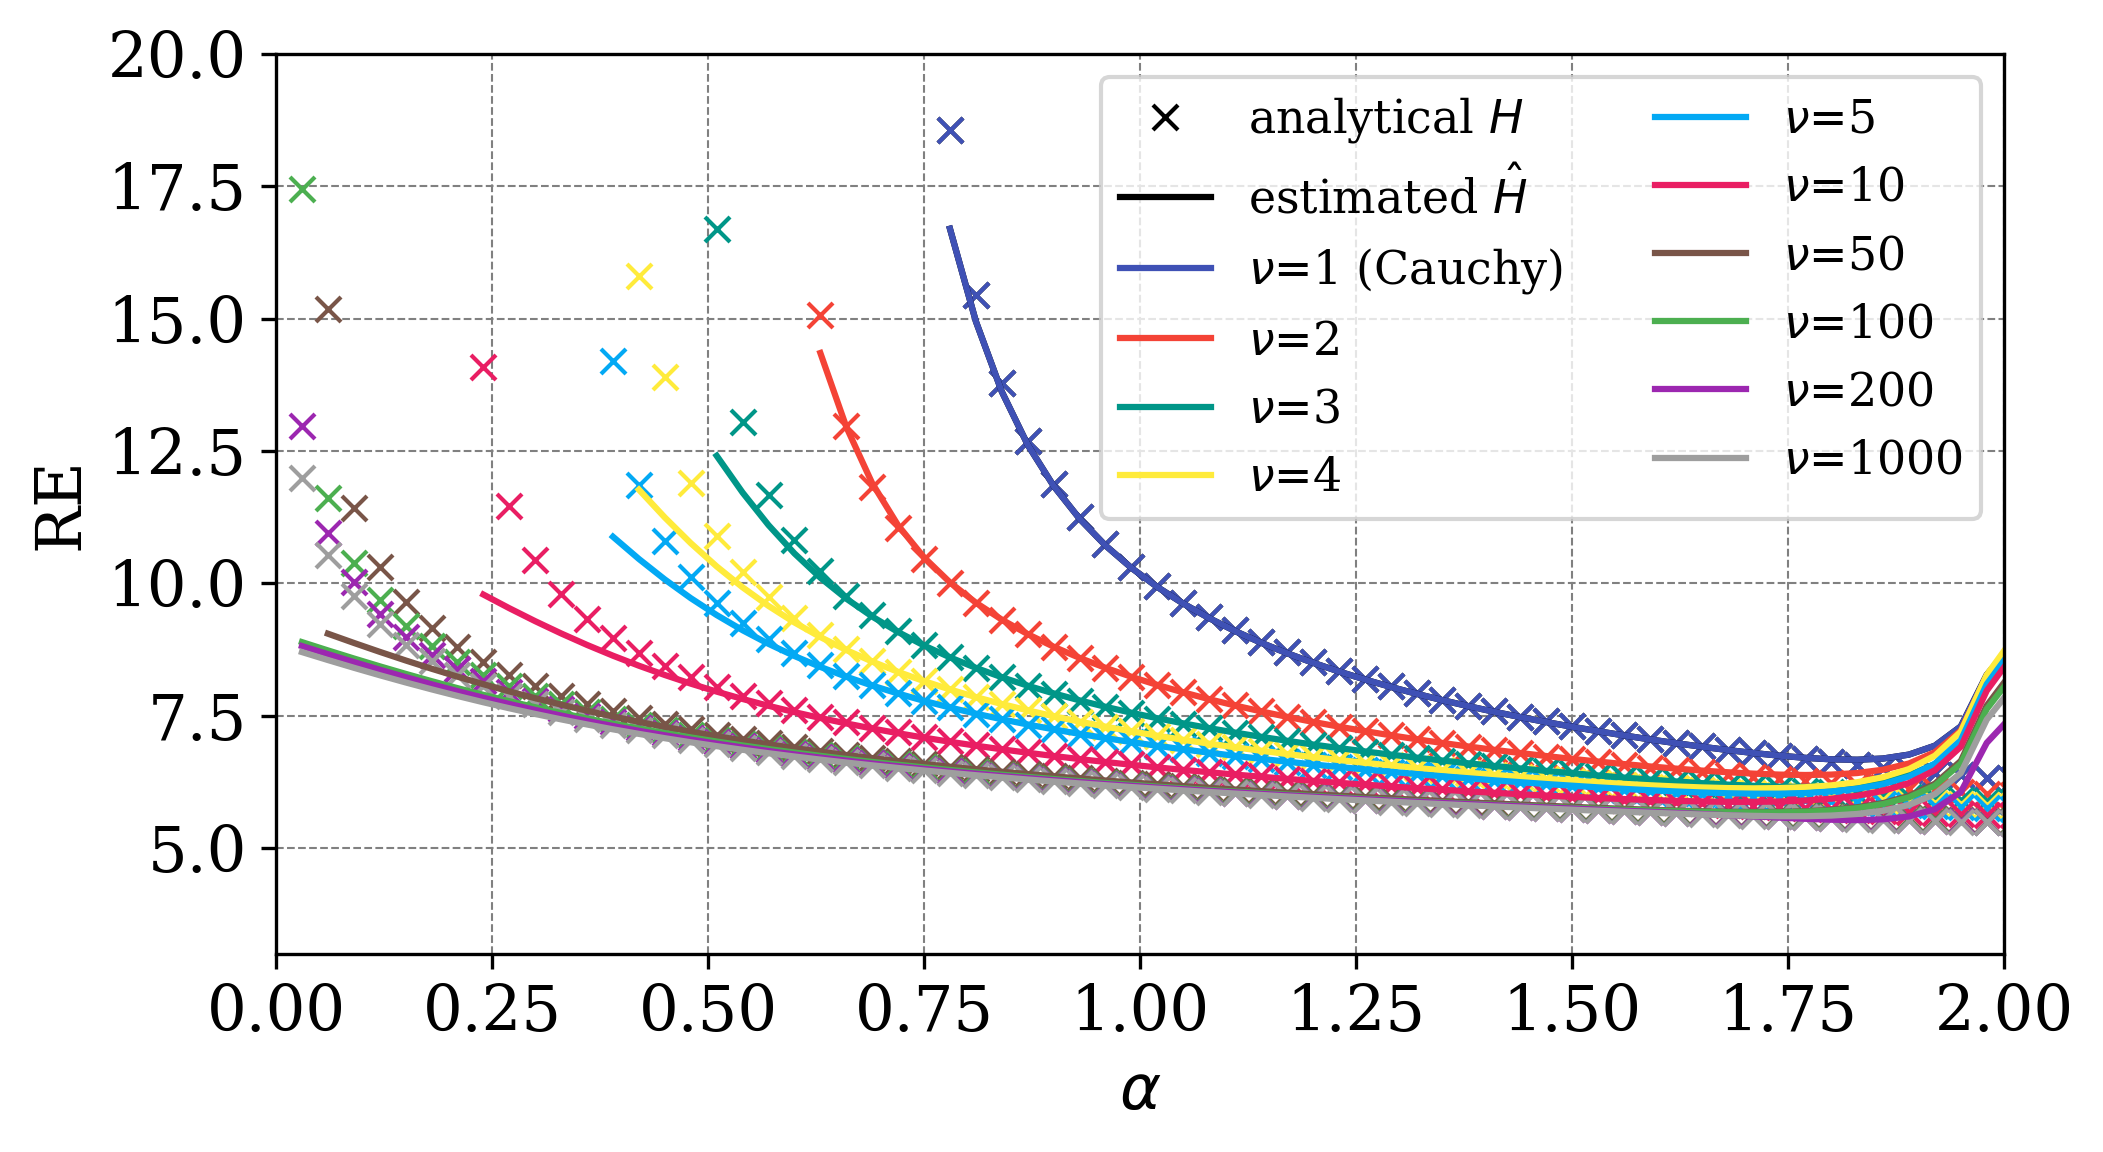

In [66]:

plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif', 
    'font.size': 15
})

fig = plt.figure(figsize=(7.2, 4.0), dpi=300)


left_margin = 0.15
right_margin = 0.95
bottom_margin = 0.15
top_margin = 0.9

ax = fig.add_axes([
    left_margin,
    bottom_margin,
    right_margin - left_margin,
    top_margin - bottom_margin
])

df_labels=[1,2,3,4,5,10,50,100,200,1000]

ax.plot(alphas[25:],analytical_st[0][25:], "x", c='k', label=r'analytical $H$')

ax.plot(alphas[25:],analytical_st[0][25:], "x", c=primary_colors[4])
ax.plot(alphas[20:],analytical_st[1][20:], "x", c=primary_colors[0])
ax.plot(alphas[16:],analytical_st[2][16:], "x", c=primary_colors[8])
ax.plot(alphas[13:],analytical_st[3][13:], "x", c=primary_colors[12])
ax.plot(alphas[12:],analytical_st[4][12:], "x", c=primary_colors[6])
ax.plot(alphas[7:],analytical_st[5][7:], "x", c=primary_colors[1])
ax.plot(alphas[1:],analytical_st[6][1:], "x", c=primary_colors[16])
ax.plot(alphas[0:],analytical_st[7][0:], "x", c=primary_colors[9])
ax.plot(alphas[0:],analytical_st[8][0:], "x", c=primary_colors[2])
ax.plot(alphas[0:],analytical_st[9][0:], "x", c=primary_colors[17])



ax.plot(alphas[25:],estimated_means_nu[0][25:], label=r'estimated $\hat{H}$', c='k')

ax.plot(alphas[25:],estimated_means_nu[0][25:],label=r'$\nu$=1 (Cauchy)', c=primary_colors[4])

ax.plot(alphas[20:],estimated_means_nu[1][20:], label=r'$\nu$=2', c=primary_colors[0])
ax.plot(alphas[16:],estimated_means_nu[2][16:], label=r'$\nu$=3', c=primary_colors[8])
ax.plot(alphas[13:],estimated_means_nu[3][13:], label=r'$\nu$=4', c=primary_colors[12])
ax.plot(alphas[12:],estimated_means_nu[4][12:], label=r'$\nu$=5', c=primary_colors[6])
ax.plot(alphas[7:],estimated_means_nu[5][7:], label=r'$\nu$=10', c=primary_colors[1])
ax.plot(alphas[1:],estimated_means_nu[6][1:], label=r'$\nu$=50', c=primary_colors[16])
ax.plot(alphas[0:],estimated_means_nu[7][0:], label=r'$\nu$=100', c=primary_colors[9])
ax.plot(alphas[0:],estimated_means_nu[8][0:], label=r'$\nu$=200', c=primary_colors[2])
ax.plot(alphas[0:],estimated_means_nu[9][0:], label=r'$\nu$=1000', c=primary_colors[17])


plt.legend(loc='best',ncol=2, fontsize=11)
plt.xlabel(r'$\alpha$')
plt.ylabel(r'RE')

ax.grid(axis='x', linestyle='--', color='gray', linewidth=0.5)
ax.grid(axis='y', linestyle='--', color='gray', linewidth=0.5)


ax.set_ylim(3,20)

ax.set_xlim(0,2)


plt.show()

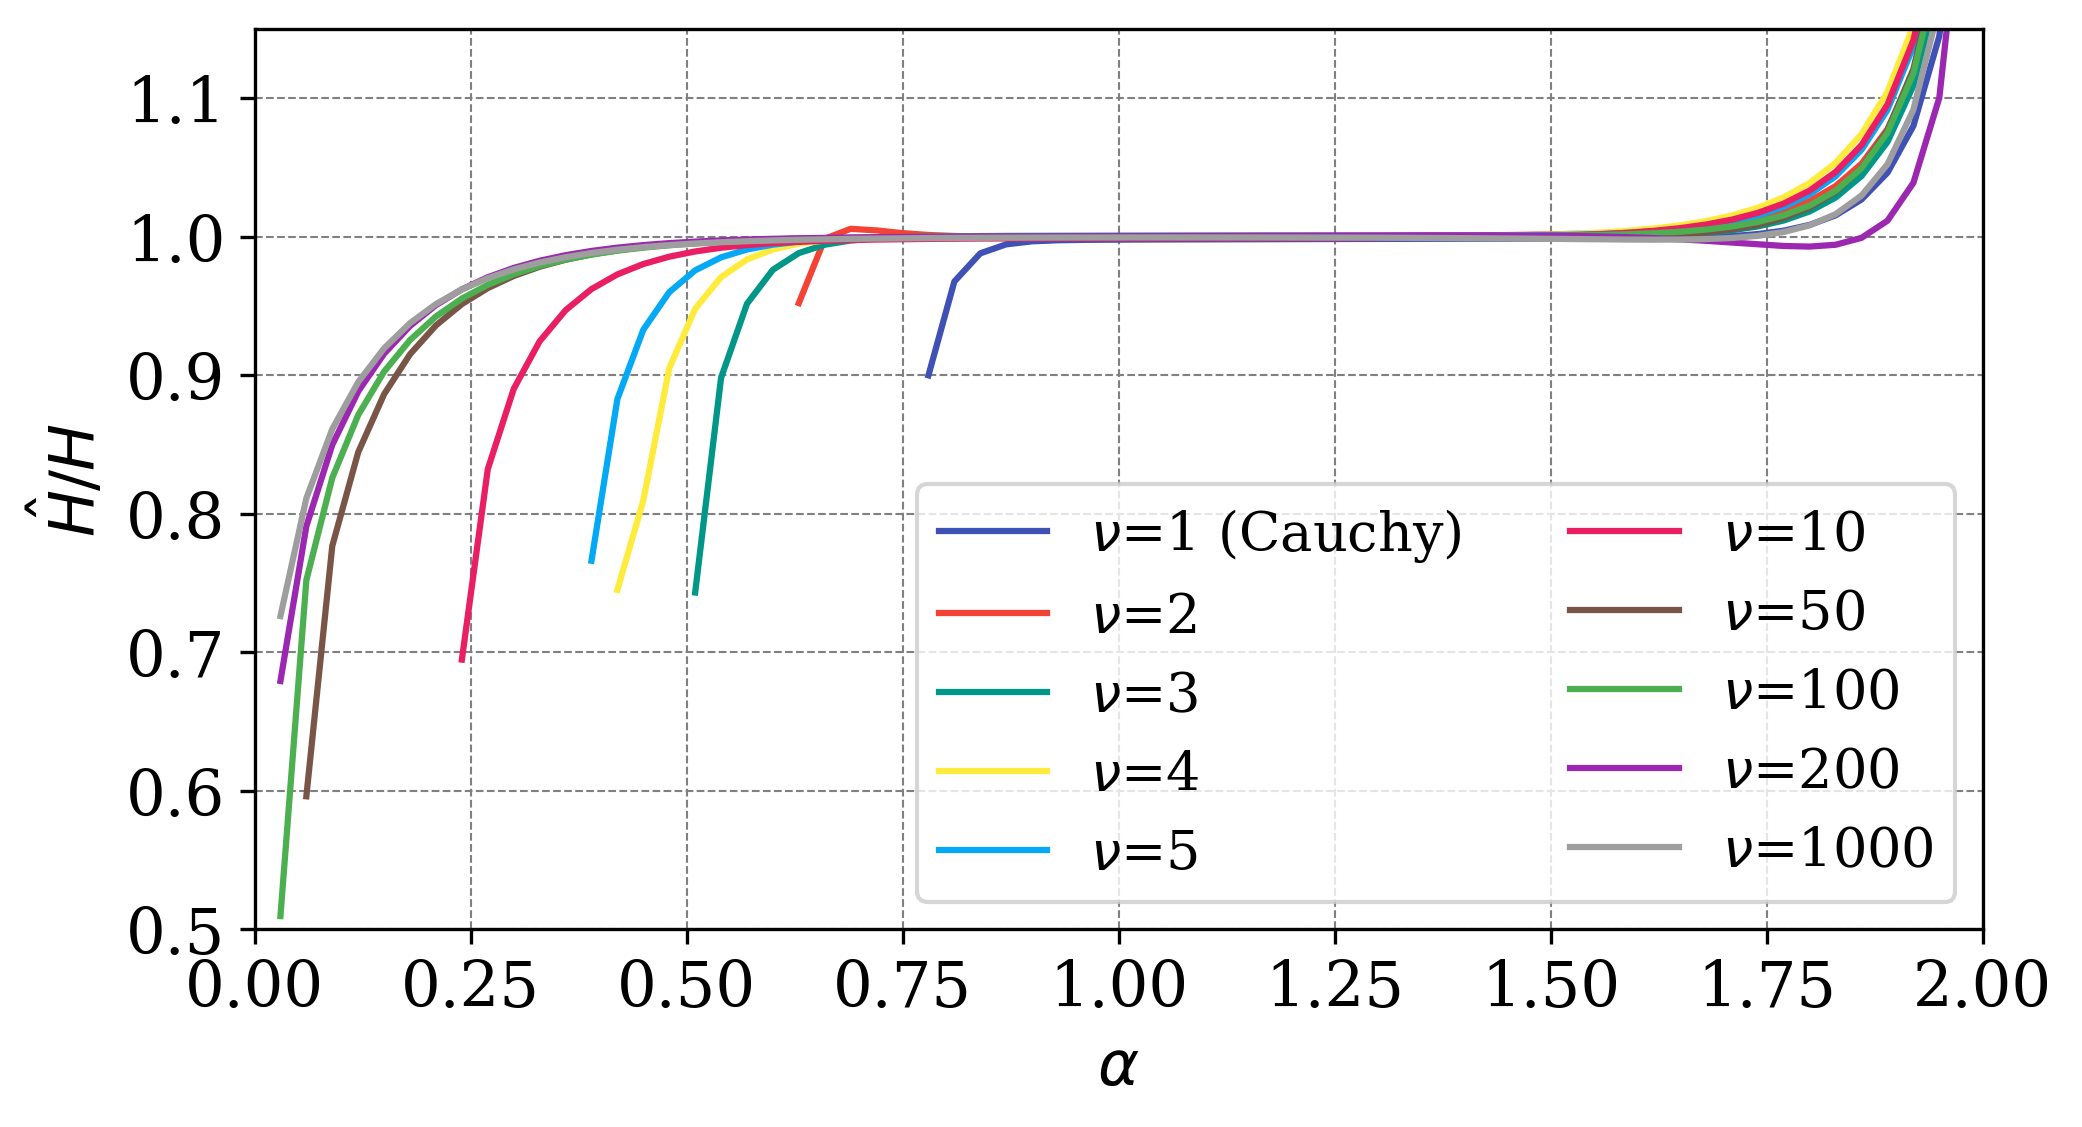

In [65]:
plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif', 
    'font.size': 15
})

fig = plt.figure(figsize=(7.2, 4.0), dpi=300)


left_margin = 0.15
right_margin = 0.95
bottom_margin = 0.15
top_margin = 0.9

ax = fig.add_axes([
    left_margin,
    bottom_margin,
    right_margin - left_margin,
    top_margin - bottom_margin
])



df_labels=[1,2,3,4,5,10,50,100,200,1000]

ax.plot(alphas[25:],estimated_means_nu[0][25:]/analytical_st[0][25:],label=r'$\nu$=1 (Cauchy)', c=primary_colors[4])
ax.plot(alphas[20:],estimated_means_nu[1][20:]/analytical_st[1][20:],label=r'$\nu$=2', c=primary_colors[0])
ax.plot(alphas[16:],estimated_means_nu[2][16:]/analytical_st[2][16:],label=r'$\nu$=3', c=primary_colors[8])
ax.plot(alphas[13:],estimated_means_nu[3][13:]/analytical_st[3][13:],label=r'$\nu$=4', c=primary_colors[12])
ax.plot(alphas[12:],estimated_means_nu[4][12:]/analytical_st[4][12:],label=r'$\nu$=5', c=primary_colors[6])
ax.plot(alphas[7:],estimated_means_nu[5][7:]/analytical_st[5][7:],label=r'$\nu$=10', c=primary_colors[1])
ax.plot(alphas[1:],estimated_means_nu[6][1:]/analytical_st[6][1:],label=r'$\nu$=50', c=primary_colors[16])
ax.plot(alphas[0:],estimated_means_nu[7][0:]/analytical_st[7][0:],label=r'$\nu$=100', c=primary_colors[9])
ax.plot(alphas[0:],estimated_means_nu[8][0:]/analytical_st[8][0:],label=r'$\nu$=200', c=primary_colors[2])
ax.plot(alphas[0:],estimated_means_nu[9][0:]/analytical_st[9][0:],label=r'$\nu$=1000', c=primary_colors[17])


plt.legend(loc='best',ncol=2, fontsize=13)
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\hat{H}/H$')

ax.grid(axis='x', linestyle='--', color='gray', linewidth=0.5)
ax.grid(axis='y', linestyle='--', color='gray', linewidth=0.5)


ax.set_xlim(0,2)
ax.set_ylim(0.5,1.15)


plt.show()



# Dimensions

In [15]:
estimated_re = []

length=100000

neigh_num=[10]

dim_set = [1,2,3,4,5,6,7,8,9,10,15,20,25]
for i in dim_set:

    dim=i
    cov = np.identity(dim)
    mean = [0]*dim

    dat_norm = multivariate_t_rvs(mean=mean, cov=cov, df=1, size=length)

    H=renyi_Leonenko(neigh_num=neigh_num,alphas=alphas,data=dat_norm)

    estimated_re.append(H)


In [16]:
analytical_re_dims = []

length=100000

cov = np.identity(2)
RE_analy = [student_t_analytical_g(q=alpha,n=1,cov=cov,nu=1) for alpha in alphas] 

analytical_re_dims.append(RE_analy)

dim_set = [2,3,4,5,6,7,8,9,10,15,20,25]

for i in dim_set:

    dim=i
    cov = np.identity(dim)

    RE_analy = [student_t_analytical_g(q=alpha,n=dim,cov=cov,nu=1) for alpha in alphas] 

    analytical_re_dims.append(RE_analy)



In [17]:
estimated_means_re_dims = np.mean(np.asarray(estimated_re), axis=2)
estimated_std_re_dims = np.std(np.asarray(estimated_re), axis=2)

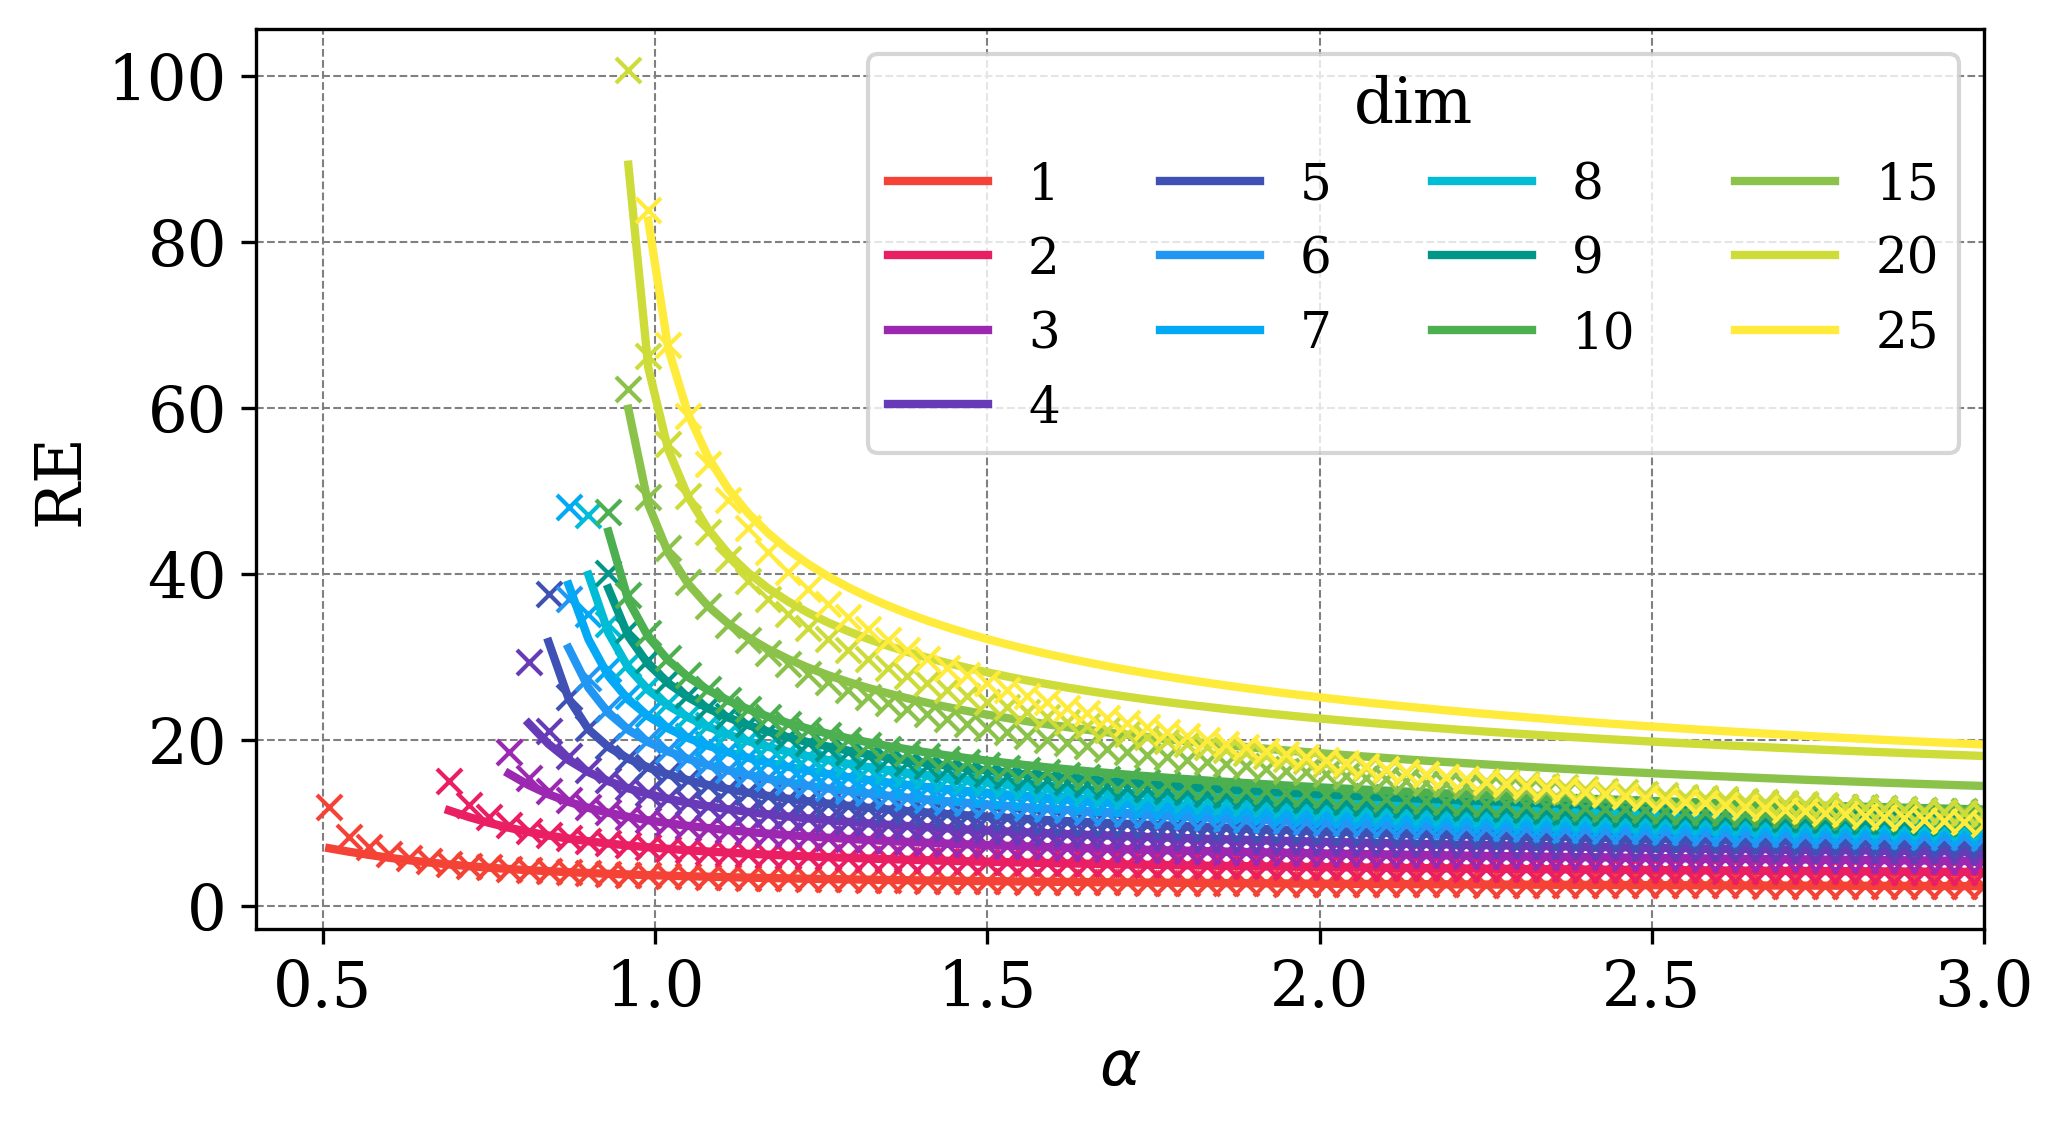

In [76]:
plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif', 
    'font.size': 15
})

fig = plt.figure(figsize=(7.2, 4.0), dpi=300)


left_margin = 0.15
right_margin = 0.95
bottom_margin = 0.15
top_margin = 0.9

ax = fig.add_axes([
    left_margin,
    bottom_margin,
    right_margin - left_margin,
    top_margin - bottom_margin
])

labels_dim=[1,2,3,4,5,6,7,8,9,10,15,20,25]


ax.plot(alphas[16:],np.asarray(estimated_means_re_dims)[0,16:],linewidth=2, label=labels_dim[0],c=primary_colors[0])
ax.plot(alphas[16:],np.asarray(analytical_re_dims)[0,16:],'x', linewidth=2,c=primary_colors[0])

ax.plot(alphas[22:],np.asarray(estimated_means_re_dims)[1,22:], linewidth=2, label=labels_dim[1],c=primary_colors[1])
ax.plot(alphas[22:],np.asarray(analytical_re_dims)[1,22:],'x', linewidth=2,c=primary_colors[1])

ax.plot(alphas[25:],np.asarray(estimated_means_re_dims)[2,25:], linewidth=2, label=labels_dim[2],c=primary_colors[2])
ax.plot(alphas[25:],np.asarray(analytical_re_dims)[2,25:],'x', linewidth=2,c=primary_colors[2])

ax.plot(alphas[26:],np.asarray(estimated_means_re_dims)[3,26:],linewidth=2, label=labels_dim[3],c=primary_colors[3])
ax.plot(alphas[26:],np.asarray(analytical_re_dims)[3,26:],'x', linewidth=2,c=primary_colors[3])

ax.plot(alphas[27:],np.asarray(estimated_means_re_dims)[4,27:], linewidth=2, label=labels_dim[4],c=primary_colors[4])
ax.plot(alphas[27:],np.asarray(analytical_re_dims)[4,27:],'x', linewidth=2,c=primary_colors[4])



ax.plot(alphas[28:],np.asarray(estimated_means_re_dims)[5,28:], linewidth=2, label=labels_dim[5],c=primary_colors[5])
ax.plot(alphas[28:],np.asarray(analytical_re_dims)[5,28:],'x', linewidth=2,c=primary_colors[5])

ax.plot(alphas[28:],np.asarray(estimated_means_re_dims)[6,28:], linewidth=2, label=labels_dim[6],c=primary_colors[6])
ax.plot(alphas[28:],np.asarray(analytical_re_dims)[6,28:],'x', linewidth=2,c=primary_colors[6])

ax.plot(alphas[29:],np.asarray(estimated_means_re_dims)[7,29:], linewidth=2, label=labels_dim[7],c=primary_colors[7])
ax.plot(alphas[29:],np.asarray(analytical_re_dims)[7,29:],'x', linewidth=2,c=primary_colors[7])

ax.plot(alphas[30:],np.asarray(estimated_means_re_dims)[8,30:], linewidth=2, label=labels_dim[8],c=primary_colors[8])
ax.plot(alphas[30:],np.asarray(analytical_re_dims)[8,30:],'x', linewidth=2,c=primary_colors[8])


ax.plot(alphas[30:],np.asarray(estimated_means_re_dims)[9,30:], linewidth=2, label=labels_dim[9],c=primary_colors[9])
ax.plot(alphas[30:],np.asarray(analytical_re_dims)[9,30:],'x', linewidth=2,c=primary_colors[9])


ax.plot(alphas[31:],np.asarray(estimated_means_re_dims)[10,31:],linewidth=2, label=labels_dim[10],c=primary_colors[10])
ax.plot(alphas[31:],np.asarray(analytical_re_dims)[10,31:],'x', linewidth=2,c=primary_colors[10])

ax.plot(alphas[31:],np.asarray(estimated_means_re_dims)[11,31:], linewidth=2, label=labels_dim[11],c=primary_colors[11])
ax.plot(alphas[31:],np.asarray(analytical_re_dims)[11,31:],'x', linewidth=2,c=primary_colors[11])

ax.plot(alphas[32:],np.asarray(estimated_means_re_dims)[12,32:],linewidth=2, label=labels_dim[12],c=primary_colors[12])
ax.plot(alphas[32:],np.asarray(analytical_re_dims)[12,32:],'x', linewidth=2,c=primary_colors[12])


ax.grid(axis='x', linestyle='--', color='gray', linewidth=0.5)
ax.grid(axis='y', linestyle='--', color='gray', linewidth=0.5)


plt.xlim(0.4, 3)

plt.legend(loc='best',title=r'dim', ncol=4, fontsize=12)
plt.xlabel(r'$\alpha$')
plt.ylabel(r'RE')



plt.show()

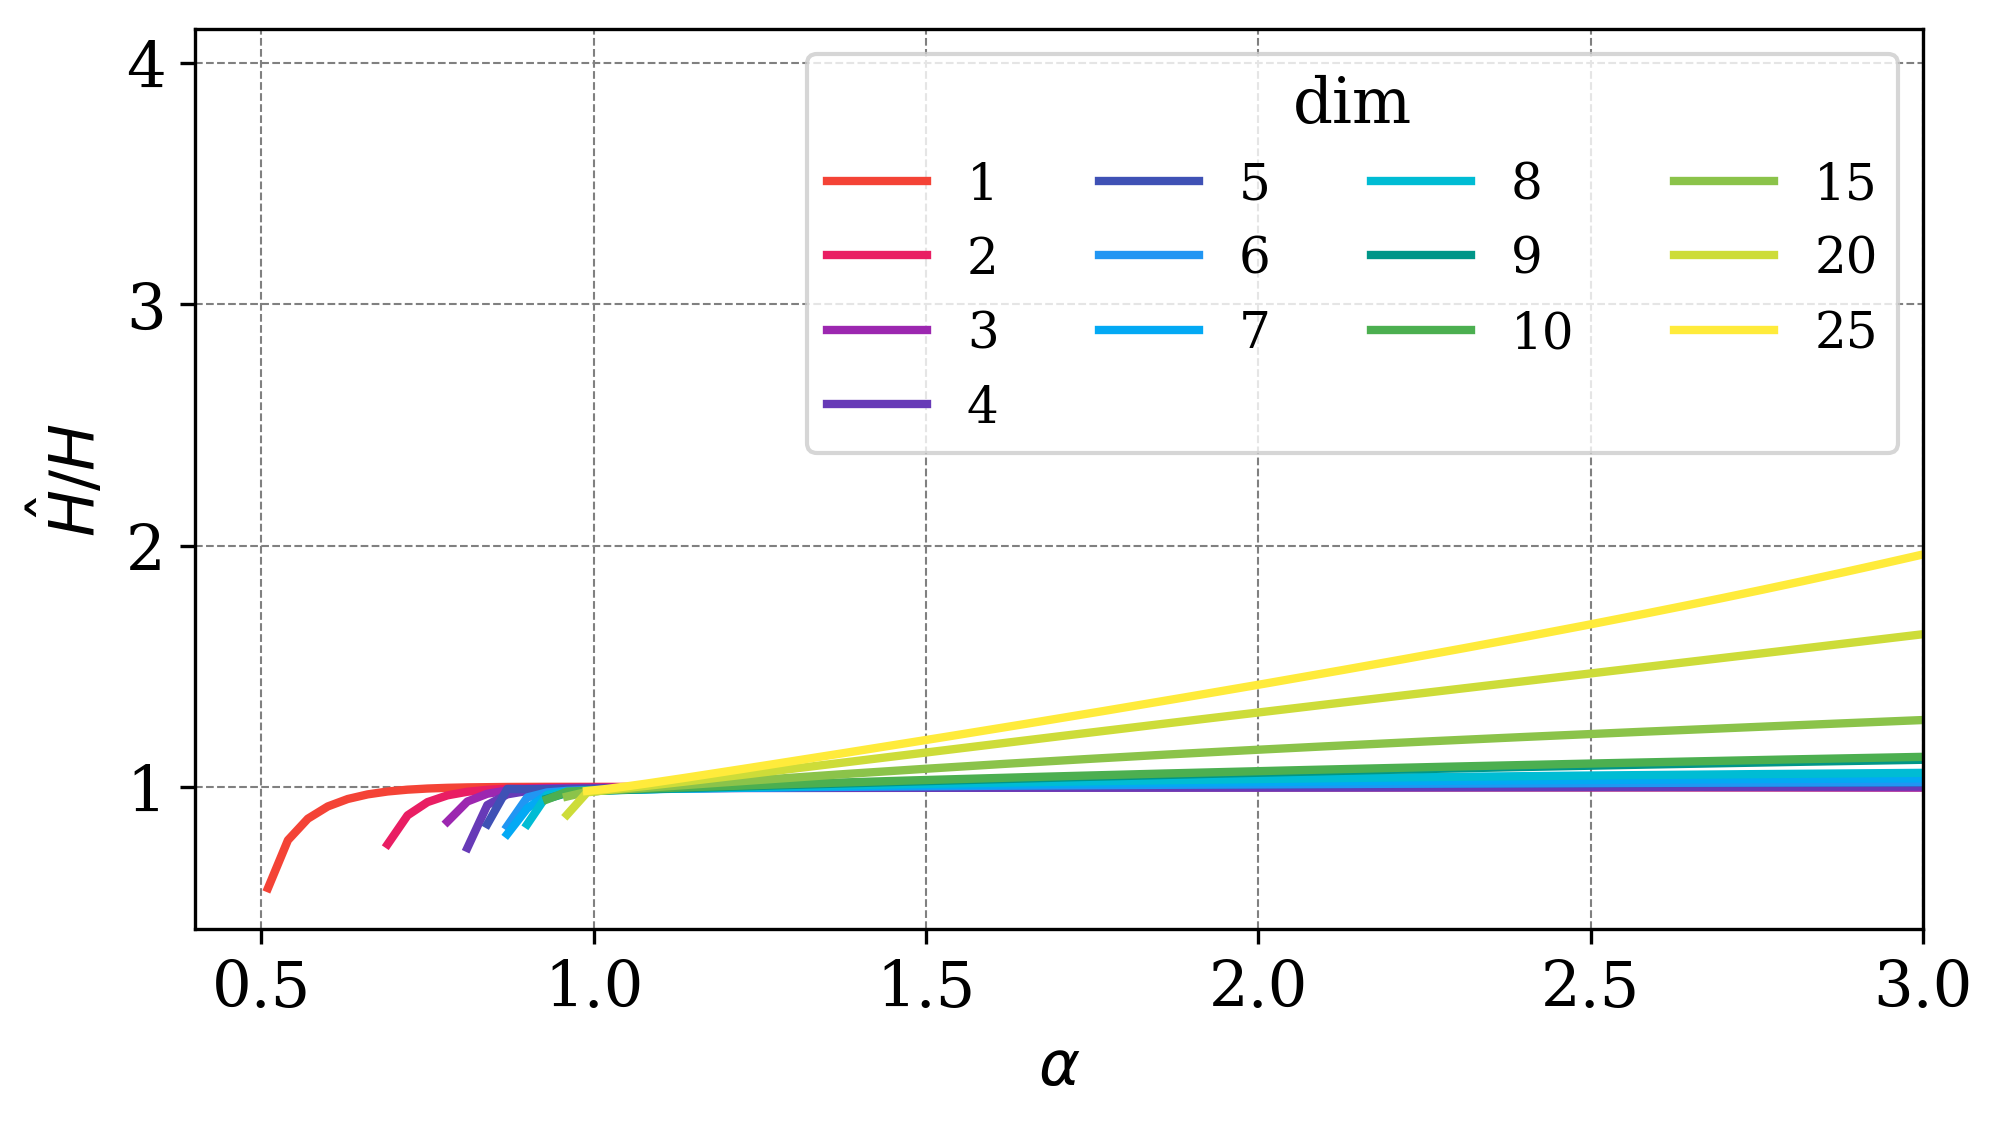

In [77]:
plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif', 
    'font.size': 15
})

fig = plt.figure(figsize=(7.2, 4.0), dpi=300)


left_margin = 0.15
right_margin = 0.95
bottom_margin = 0.15
top_margin = 0.9

ax = fig.add_axes([
    left_margin,
    bottom_margin,
    right_margin - left_margin,
    top_margin - bottom_margin
])



labels_dim=[1,2,3,4,5,6,7,8,9,10,15,20,25]


ax.plot(alphas[16:], np.asarray(estimated_means_re_dims)[0,16:]/np.asarray(analytical_re_dims)[0,16:], linewidth=2, label=labels_dim[0],c=primary_colors[0])


ax.plot(alphas[22:],np.asarray(estimated_means_re_dims)[1,22:]/np.asarray(analytical_re_dims)[1,22:],linewidth=2, label=labels_dim[1],c=primary_colors[1])


ax.plot(alphas[25:],np.asarray(estimated_means_re_dims)[2,25:]/np.asarray(analytical_re_dims)[2,25:], linewidth=2, label=labels_dim[2],c=primary_colors[2])


ax.plot(alphas[26:],np.asarray(estimated_means_re_dims)[3,26:]/np.asarray(analytical_re_dims)[3,26:], linewidth=2, label=labels_dim[3],c=primary_colors[3])


ax.plot(alphas[27:],np.asarray(estimated_means_re_dims)[4,27:]/np.asarray(analytical_re_dims)[4,27:], linewidth=2, label=labels_dim[4],c=primary_colors[4])



ax.plot(alphas[28:],np.asarray(estimated_means_re_dims)[5,28:]/np.asarray(analytical_re_dims)[5,28:], linewidth=2, label=labels_dim[5],c=primary_colors[5])


ax.plot(alphas[28:],np.asarray(estimated_means_re_dims)[6,28:]/np.asarray(analytical_re_dims)[6,28:], linewidth=2, label=labels_dim[6],c=primary_colors[6])


ax.plot(alphas[29:],np.asarray(estimated_means_re_dims)[7,29:]/np.asarray(analytical_re_dims)[7,29:], linewidth=2, label=labels_dim[7],c=primary_colors[7])


ax.plot(alphas[30:],np.asarray(estimated_means_re_dims)[8,30:]/np.asarray(analytical_re_dims)[8,30:], linewidth=2, label=labels_dim[8],c=primary_colors[8])


ax.plot(alphas[30:],np.asarray(estimated_means_re_dims)[9,30:]/np.asarray(analytical_re_dims)[9,30:], linewidth=2, label=labels_dim[9],c=primary_colors[9])


ax.plot(alphas[31:],np.asarray(estimated_means_re_dims)[10,31:]/np.asarray(analytical_re_dims)[10,31:],linewidth=2, label=labels_dim[10],c=primary_colors[10])


ax.plot(alphas[31:],np.asarray(estimated_means_re_dims)[11,31:]/np.asarray(analytical_re_dims)[11,31:], linewidth=2, label=labels_dim[11],c=primary_colors[11])


ax.plot(alphas[32:],np.asarray(estimated_means_re_dims)[12,32:]/np.asarray(analytical_re_dims)[12,32:], linewidth=2, label=labels_dim[12],c=primary_colors[12])


ax.grid(axis='x', linestyle='--', color='gray', linewidth=0.5)
ax.grid(axis='y', linestyle='--', color='gray', linewidth=0.5)

plt.xlim(0.4, 3)


plt.legend(loc='best',title=r'dim', ncol=4, fontsize=12)
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\hat{H}/H$')


plt.show()

# Neighbours

In [19]:
estimated_re_c = []

length=100000

neigh_num=[1,2,3,10,50,100,1000]

dim=3
cov = np.identity(dim)
mean = [0]*dim

dat_norm = multivariate_t_rvs(mean=mean, cov=cov, df=1, size=length)


for i in neigh_num:

    H=renyi_Leonenko(neigh_num=[i],alphas=alphas,data=dat_norm)

    estimated_re_c.append(H)


RE_analy_cauchy = [student_t_analytical_g(q=alpha,n=dim,cov=cov,nu=1) for alpha in alphas] 
RE_analy_norm3 = [RE_analytical(d=dim,alpha=alpha,cov=cov) for alpha in alphas] 

In [20]:
RE_analy_stud3 = [student_t_analytical_g(q=alpha,n=dim,cov=cov,nu=5) for alpha in alphas] 

In [21]:
k_colors=[primary_colors[0], primary_colors[4], primary_colors[17], primary_colors[9], primary_colors[8], primary_colors[12], primary_colors[16], primary_colors[18], primary_colors[13]]

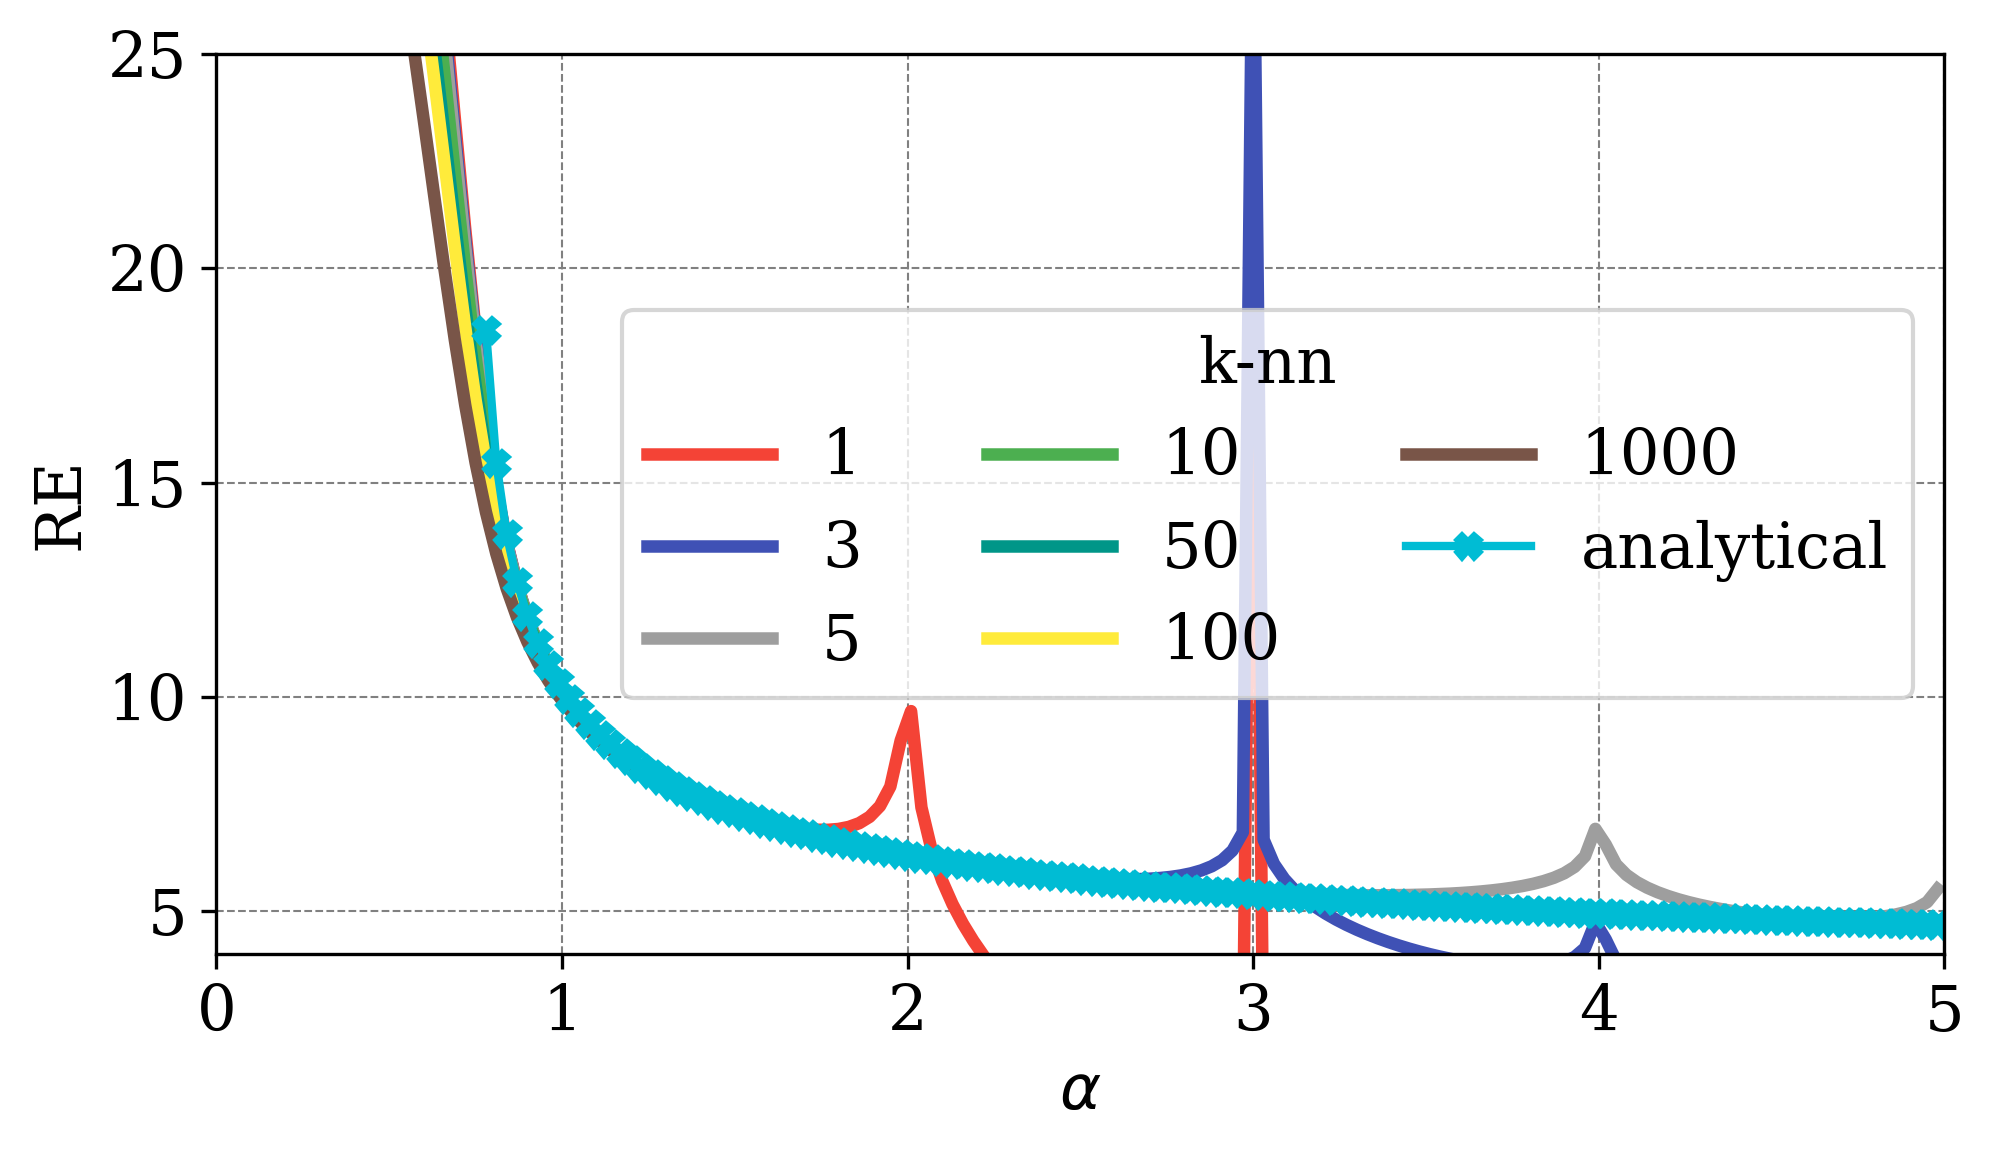

In [82]:
plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif', 
    'font.size': 15
})


fig = plt.figure(figsize=(7.2, 4.0), dpi=300)


left_margin = 0.15
right_margin = 0.95
bottom_margin = 0.15
top_margin = 0.9

ax = fig.add_axes([
    left_margin,
    bottom_margin,
    right_margin - left_margin,
    top_margin - bottom_margin
])



legend_n=[1,3,5,10,50,100,1000]


for i in range(0,7):
    plt.plot(alphas,np.asarray(estimated_re_c)[i,:,:], linewidth=3, label=legend_n[i], c=k_colors[i])

plt.plot(alphas[25:],np.asarray(RE_analy_cauchy)[25:],marker='X', c=primary_colors[7], linewidth=2, label=r'analytical')

plt.ylim(4, 25)
plt.xlim(0, 5)



ax.grid(axis='x', linestyle='--', color='gray', linewidth=0.5)
ax.grid(axis='y', linestyle='--', color='gray', linewidth=0.5)

plt.legend(loc='best',title='k-nn',ncol=3)
plt.xlabel(r'$\alpha$')
plt.ylabel(r'RE')


plt.show()

# Size

In [83]:
estimated_re_s = []

length=[100,1000,2000,5000,7000,10000,100000,1000000]

neigh_num=[10]
dim=3
cov = np.identity(dim)
mean = [0]*dim


for i in length:

    dat_norm = multivariate_t_rvs(mean=mean, cov=cov, df=1, size=i)

    H=renyi_Leonenko(neigh_num=neigh_num,alphas=alphas,data=dat_norm)

    estimated_re_s.append(H)


#RE_analy_stud3 = [student_t_analytical(q=alpha,n=dim,cov=cov,nu=1) for alpha in alphas] 

In [84]:
estimated_means_re_size = np.mean(np.asarray(estimated_re_s), axis=2)
estimated_std_re_size = np.std(np.asarray(estimated_re_s), axis=2)

In [30]:
def RE_analytical(d, alpha, cov):
    RE = np.log2((2*np.pi)**(d/2)* (np.linalg.det(cov))**0.5) + (1/(1-alpha))*np.log2(alpha**(-d/2))
    return RE

In [31]:
cov = np.identity(3)
RE_analy_norm = [RE_analytical(d=3,alpha=alpha,cov=cov) for alpha in alphas] 

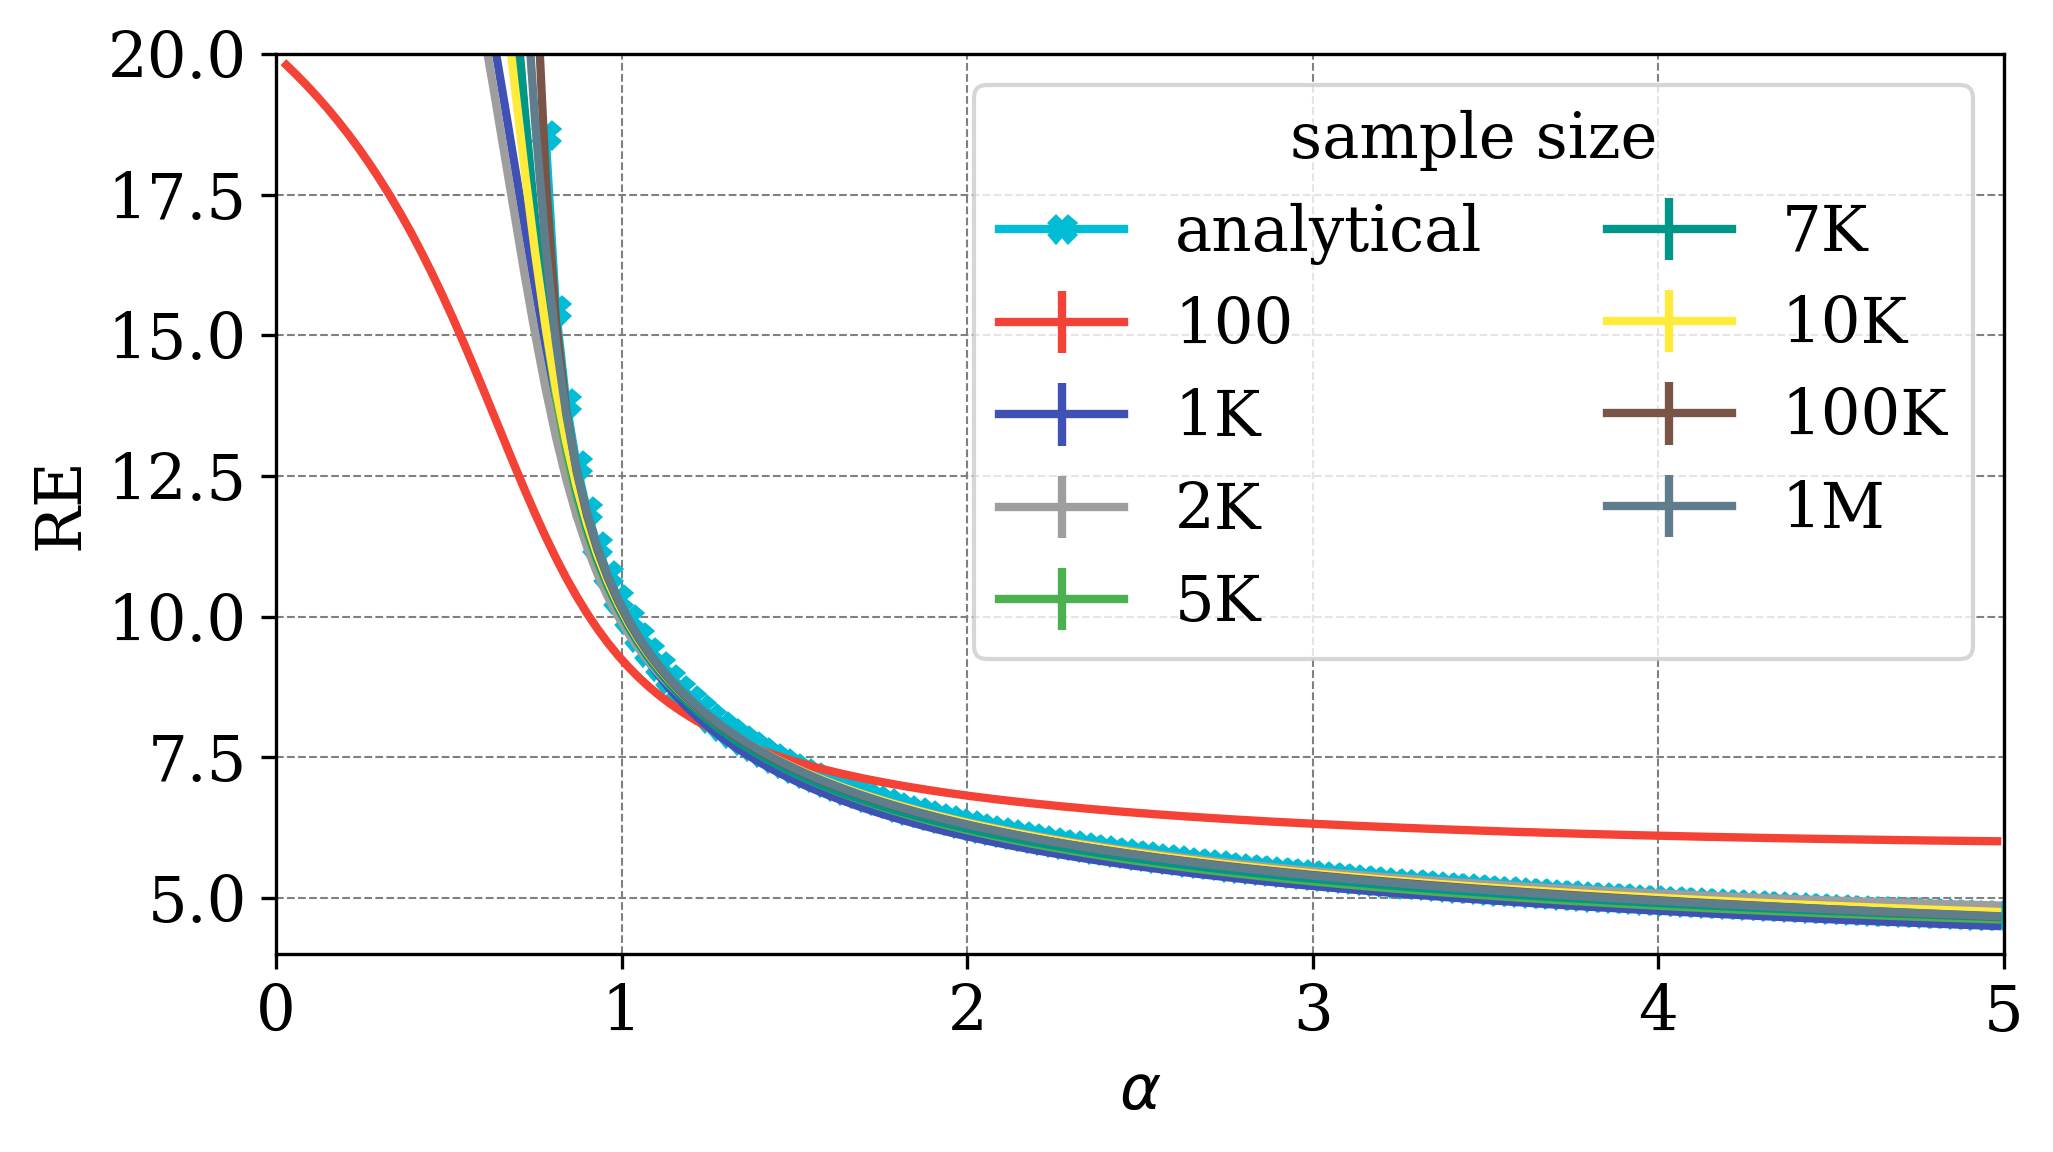

In [89]:
plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',  
    'font.size': 15
})

fig = plt.figure(figsize=(7.2, 4.0), dpi=300)


left_margin = 0.15
right_margin = 0.95
bottom_margin = 0.15
top_margin = 0.9

ax = fig.add_axes([
    left_margin,
    bottom_margin,
    right_margin - left_margin,
    top_margin - bottom_margin
])


labels_len=["100","1K","2K","5K","7K","10K","100K","1M"]

for i in range(0,8):
    plt.errorbar(alphas,np.asarray(estimated_means_re_size)[i,:,],np.asarray(estimated_std_re_size)[i,:,], linewidth=2, label=labels_len[i], c=k_colors[i])

    ax.grid(axis='x', linestyle='--', color='gray', linewidth=0.5)
ax.grid(axis='y', linestyle='--', color='gray', linewidth=0.5)


plt.plot(alphas[24:],np.asarray(RE_analy_cauchy)[24:],marker='X', c=primary_colors[7], linewidth=2, label=r'analytical')


plt.ylim(4, 20)
plt.xlim(0, 5)



plt.legend(loc='best',title="sample size", ncol=2)
plt.xlabel(r'$\alpha$')
plt.ylabel(r'RE')


plt.show()